# Time-frequency decomposition (Morlet wavelet)

Port of `templateCode/timeFreq` (MATLAB, Cohen-style wavelet convolution) to Python, vectorized with `scipy.signal.fftconvolve`.

1. **Validate** the decomposition on a synthetic signal with a known frequency and onset time, before trusting it on real data.
2. **Run** on a real EEGLAB run (`MET004TESTBLUE/R01.mat`), baseline-normalize against the 3 baseline trials, and plot.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from eeg.eeglab_io import BASELINE_EVENT_ID, load_eeglab_epochs
from eeg.timefreq import baseline_normalize, compute_baseline_stats, time_frequency_decompose
from eeg.viz import plot_time_frequency

## 1. Synthetic validation

One channel, several trials, a 10 Hz burst injected only in the middle third of each trial. The decomposition should show elevated power at 10 Hz, localized to that time window, and near-zero elsewhere.

In [2]:
sfreq = 512.0
n_times = 1536
n_trials = 5
n_channels = 1
burst_freq = 10.0

rng = np.random.default_rng(0)
synth = rng.standard_normal((n_trials, n_channels, n_times)) * 0.05

t = np.arange(n_times) / sfreq
lo, hi = n_times // 3, 2 * n_times // 3
burst = np.zeros(n_times)
burst[lo:hi] = np.sin(2 * np.pi * burst_freq * t[lo:hi])
synth += burst[None, None, :]

print(f"burst window: {t[lo]:.2f}-{t[hi]:.2f} s, expected peak frequency: {burst_freq} Hz")

burst window: 1.00-2.00 s, expected peak frequency: 10.0 Hz


detected peak: 10.0 Hz at t=1.31 s
OK: decomposition recovers the injected frequency and timing.


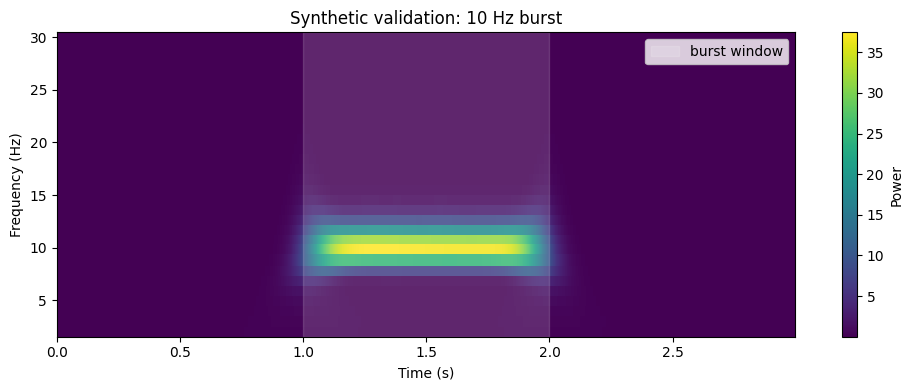

In [3]:
tf_synth, frex_synth = time_frequency_decompose(
    synth, sfreq, freq_range=(2, 30), n_freqs=30, n_cycles_range=(4, 10)
)
power = tf_synth[0].mean(axis=-1)  # (n_freqs, n_times), averaged over trials

peak_freq_idx, peak_time_idx = np.unravel_index(np.argmax(power), power.shape)
print(f"detected peak: {frex_synth[peak_freq_idx]:.1f} Hz at t={t[peak_time_idx]:.2f} s")
assert abs(frex_synth[peak_freq_idx] - burst_freq) < 1.0, "peak frequency should match the injected burst"
assert t[lo] < t[peak_time_idx] < t[hi], "peak should fall inside the burst window"
print("OK: decomposition recovers the injected frequency and timing.")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(t, frex_synth, power, shading="auto", cmap="viridis")
plt.colorbar(im, ax=ax, label="Power")
ax.axvspan(t[lo], t[hi], color="white", alpha=0.15, label="burst window")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Synthetic validation: 10 Hz burst")
ax.legend(loc="upper right")
fig.tight_layout()

## 2. Real data — MET004TESTBLUE, R01

32 channels, 23 trials (3 baseline + 20 stimulus), 512 Hz, ~3 s per trial.

In [4]:
DATA_ROOT = Path("/mnt/c/Users/zevaz/OneDrive/Escritorio/Metamers/eegExp/compsRem")
PARTICIPANT = "MET004TESTBLUE"
RUN = "R01"

epochs = load_eeglab_epochs(DATA_ROOT / PARTICIPANT / f"{RUN}.mat")
print(epochs)

Not setting metadata


23 matching events found


No baseline correction applied


0 projection items activated


<EpochsArray | 23 events (all good), 0 – 2.998 s (baseline off), ~8.7 MiB, data loaded,
 'baseline': 3
 'stimulus': 20>


In [5]:
data = epochs.get_data()
sfreq = epochs.info["sfreq"]

tf, frex = time_frequency_decompose(
    data, sfreq, freq_range=(2, 30), n_freqs=50, n_cycles_range=(4, 10), include_freq=10.0
)
print(f"tf shape (channels, freqs, times, trials): {tf.shape}")
assert 10.0 in frex

tf shape (channels, freqs, times, trials): (32, 50, 1536, 23)


In [6]:
baseline_idx = epochs.events[:, 2] == BASELINE_EVENT_ID
print(f"baseline trials: {baseline_idx.sum()} of {len(baseline_idx)}")

baseline_mean, baseline_std = compute_baseline_stats(tf, baseline_idx)
tf_db = baseline_normalize(tf, baseline_mean, baseline_std, method="db")

baseline trials: 3 of 23


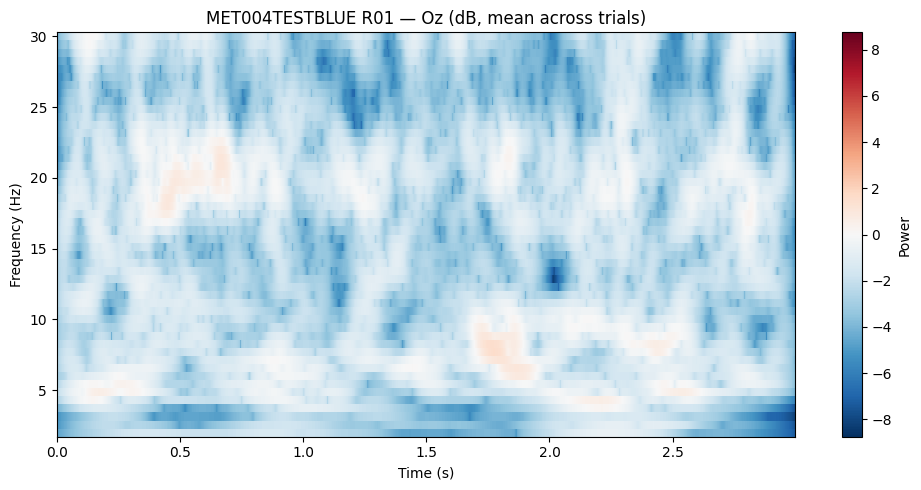

In [7]:
fig = plot_time_frequency(
    tf_db, frex, epochs.times, epochs.ch_names, channel="Oz",
    title=f"{PARTICIPANT} {RUN} \u2014 Oz (dB, mean across trials)",
)